In this notebook, we applied manual search to find an optimal parameters for Particle Filter.

The parameters to be tuned and their possible options are:
- Resampling algorithm: multinomial, redidual, stratified, and systematic resampling algorithm
- Number of samples: from 32 to 4096 samples.

Those parameters are chosen based on a balance between processing time and estimation error.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
sys.path.append('/app/src')
from data_loader import DataLoader
from configs import SetupEnum, ErrorEnum
from kalman_filters.particle_filter import ResamplingAlgorithms
from parameter_tuners.particle_filter_parameter_tuner import ParticleFilterParameterTuner


%matplotlib inline
np.random.seed(777)

In [2]:
algorithms = [ResamplingAlgorithms.MULTINOMIAL, 
              ResamplingAlgorithms.RESIDUAL, 
              ResamplingAlgorithms.STRATIFIED, 
              ResamplingAlgorithms.SYSTEMATIC]
n_samples = [int(n) for n in np.logspace(5, 11, base=2, num=7).tolist()]

params = {
    "n_samples": n_samples,
    "algorithms": algorithms,
}
n_samples

[32, 64, 128, 256, 512, 1024, 2048]

In [3]:
resampling_algorithm_str = {
    ResamplingAlgorithms.MULTINOMIAL: "MULTINOMIAL", 
    ResamplingAlgorithms.RESIDUAL: "RESIDUAL", 
    ResamplingAlgorithms.STRATIFIED: "STRATIFIED", 
    ResamplingAlgorithms.SYSTEMATIC: "SYSTEMATIC"
}

root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
file_export_path = os.path.join(root_path, "exports/particle_filter")

exporting_filename = os.path.join(file_export_path, "0016_best_params.json")

kitti_date = '2011_09_30'
kitti_drive = '0016'

run_filter = False
error_type = ErrorEnum.MAE

error_weight = 0.9

In [4]:
best_params = []
best_params_0 = []
best_params_10 = []
best_params_20 = []
best_params_30 = []
best_params_40 = []

------

# No dropout measurement data

## Setup1 (IMU, VO)

In [5]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False
)

tuner_setup1 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [6]:
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

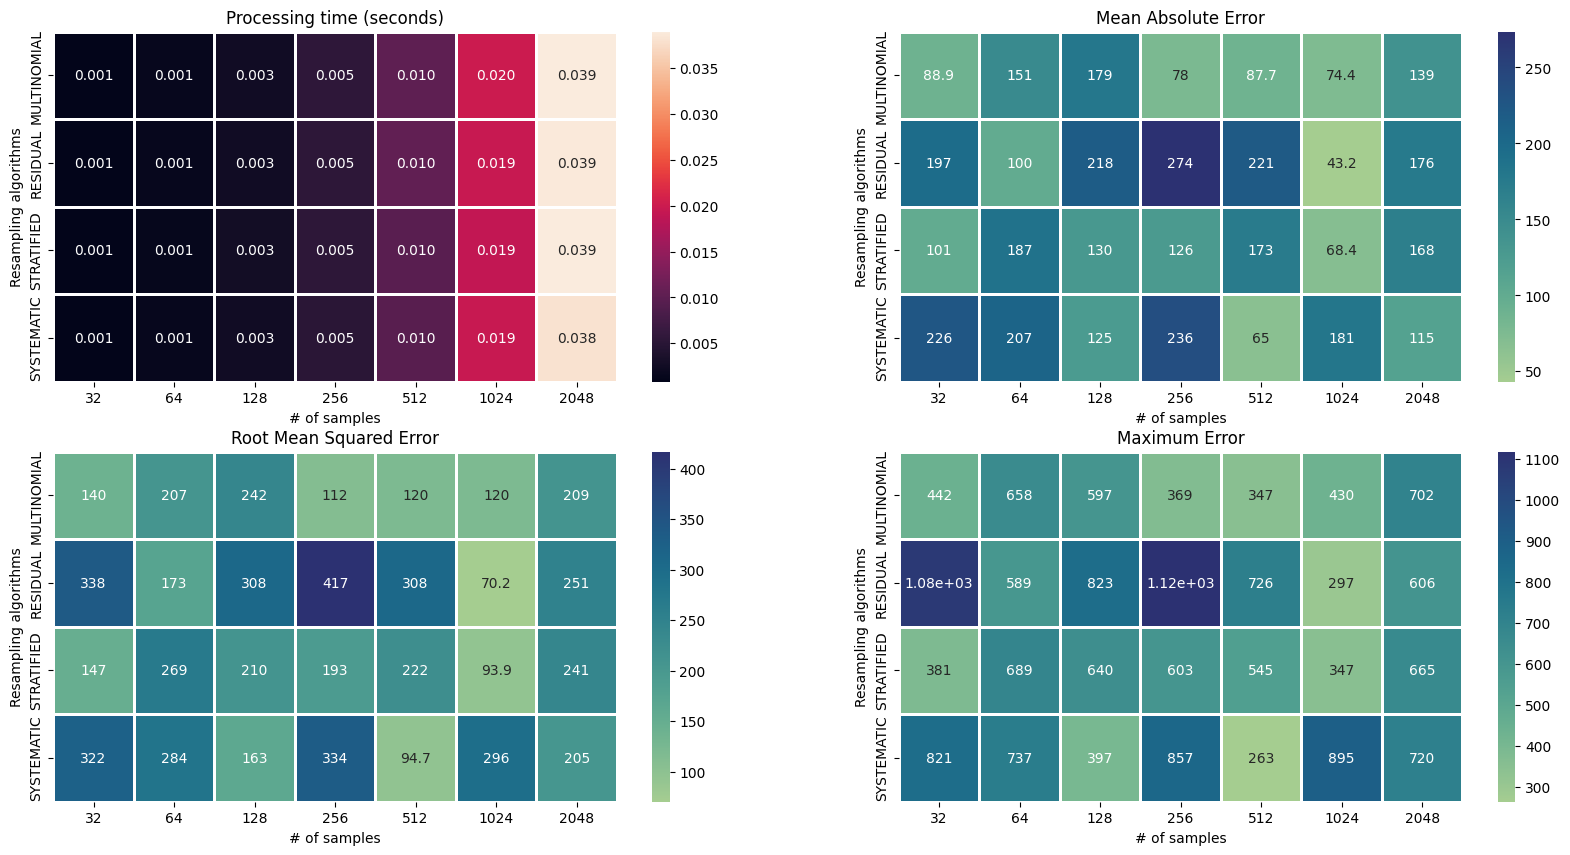

In [7]:
tuner_setup1.plot_results()

In [8]:
params_1_0, df_1_0 = tuner_setup1.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_1_0)

In [9]:
df_1_0

,# of samples,resampling algorithm
MAE,1024,RESIDUAL
RMSE,1024,RESIDUAL
MAX,512,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [10]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False
)

tuner_setup2 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [11]:
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

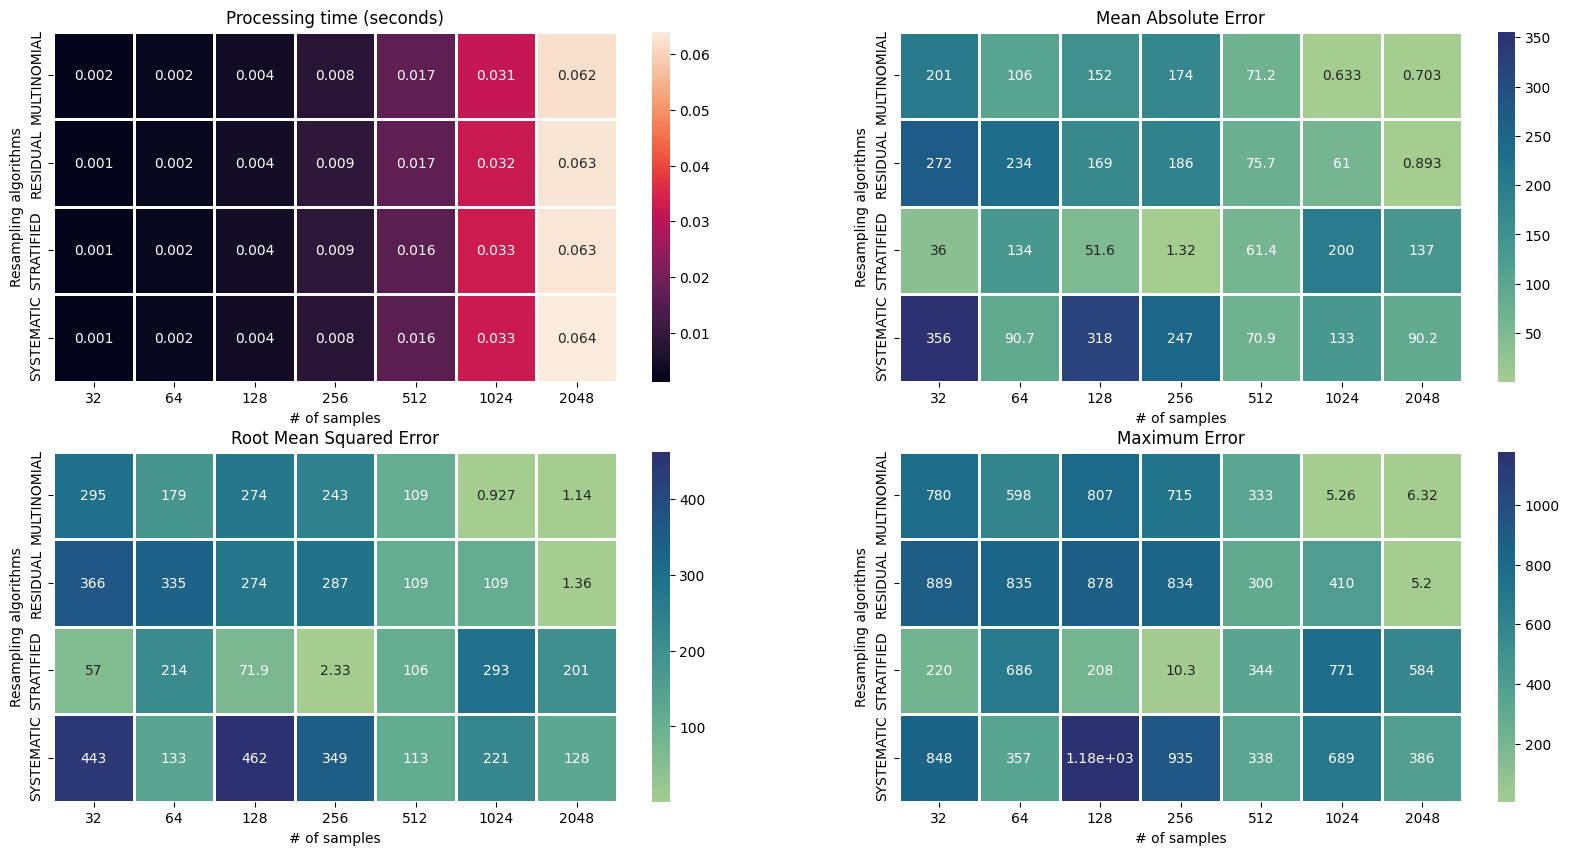

In [12]:
tuner_setup2.plot_results()

In [13]:
params_2_0, df_2_0 = tuner_setup2.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_0.append(params_2_0)

In [14]:
df_2_0

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,256,STRATIFIED
MAX,256,STRATIFIED


## Setup3 (INS)

In [15]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False
)

tuner_setup3 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [16]:
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

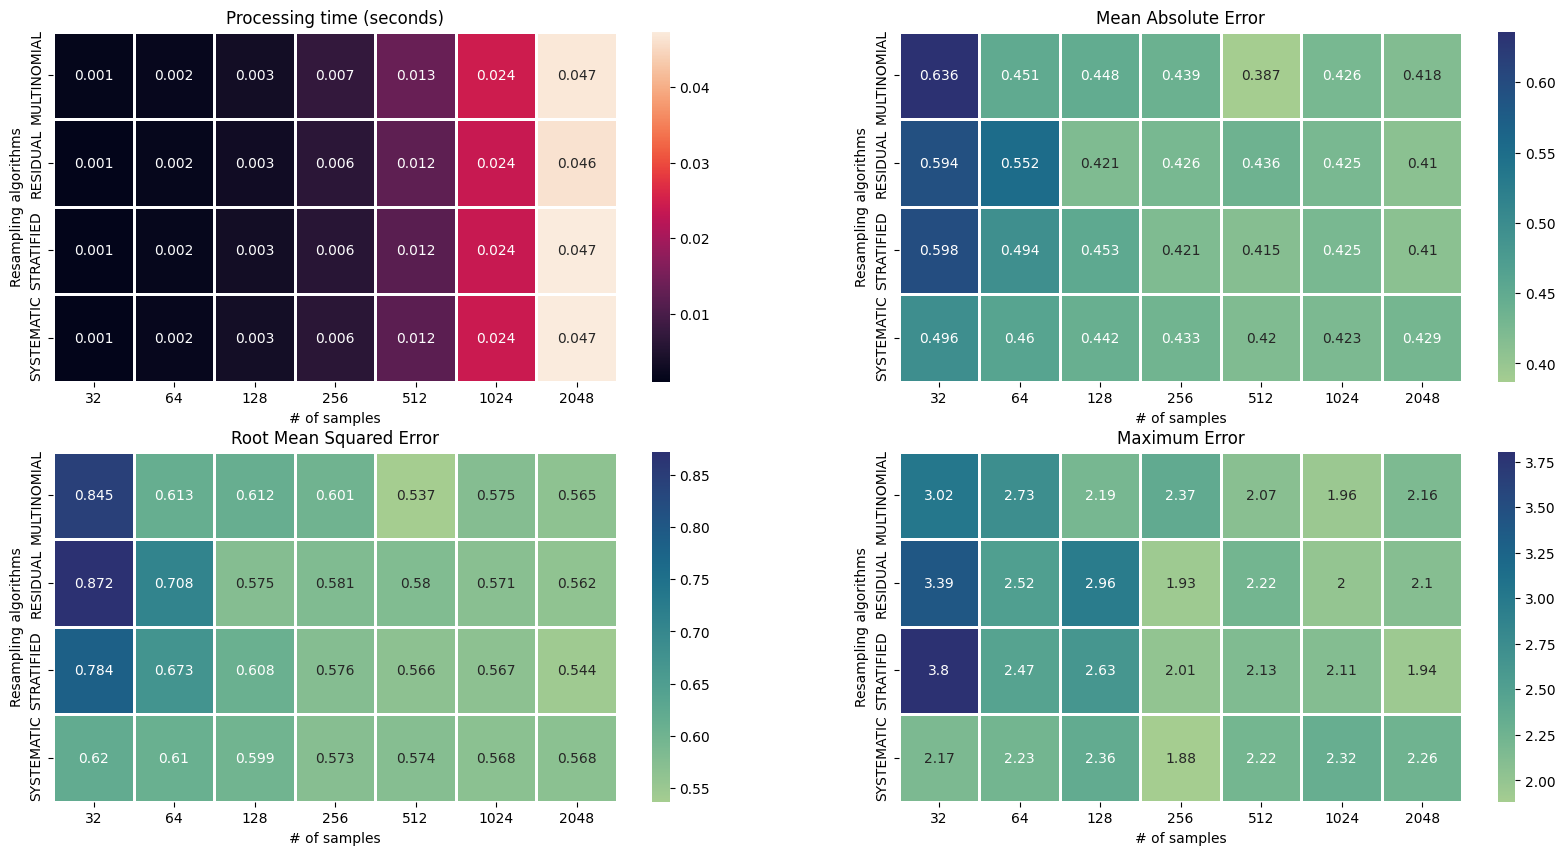

In [17]:
tuner_setup3.plot_results()

In [18]:
params_3_0, df_3_0 = tuner_setup3.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_3_0)

In [19]:
df_3_0

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,256,SYSTEMATIC


# 10% dropout measurement data

In [20]:
vo_dropout_ratio = 0.1
gps_dropout_ratio = 0.1

## Setup1 (IMU, VO)

In [21]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [22]:
if run_filter:
    tuner_setup1_10.run()
else:
    tuner_setup1_10.load_df()

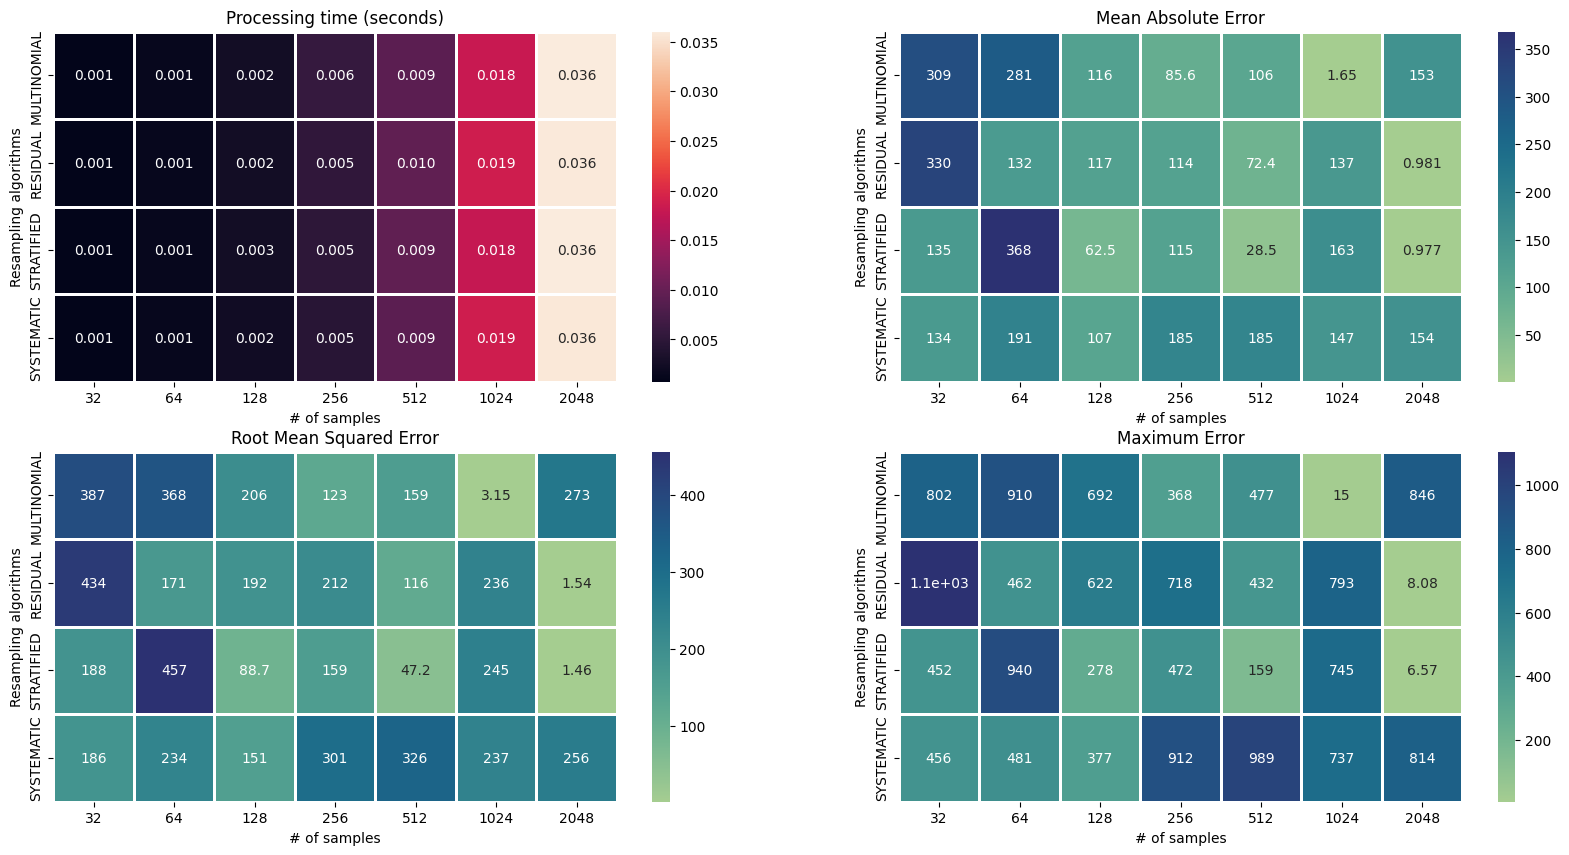

In [23]:
tuner_setup1_10.plot_results()

In [24]:
params_1_10, df_1_10 = tuner_setup1_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_1_10)

In [25]:
df_1_10

,# of samples,resampling algorithm
MAE,1024,MULTINOMIAL
RMSE,1024,MULTINOMIAL
MAX,1024,MULTINOMIAL


## Setup2 (IMU, VO+GPS)

In [26]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [27]:
if run_filter:
    tuner_setup2_10.run()
else:
    tuner_setup2_10.load_df()

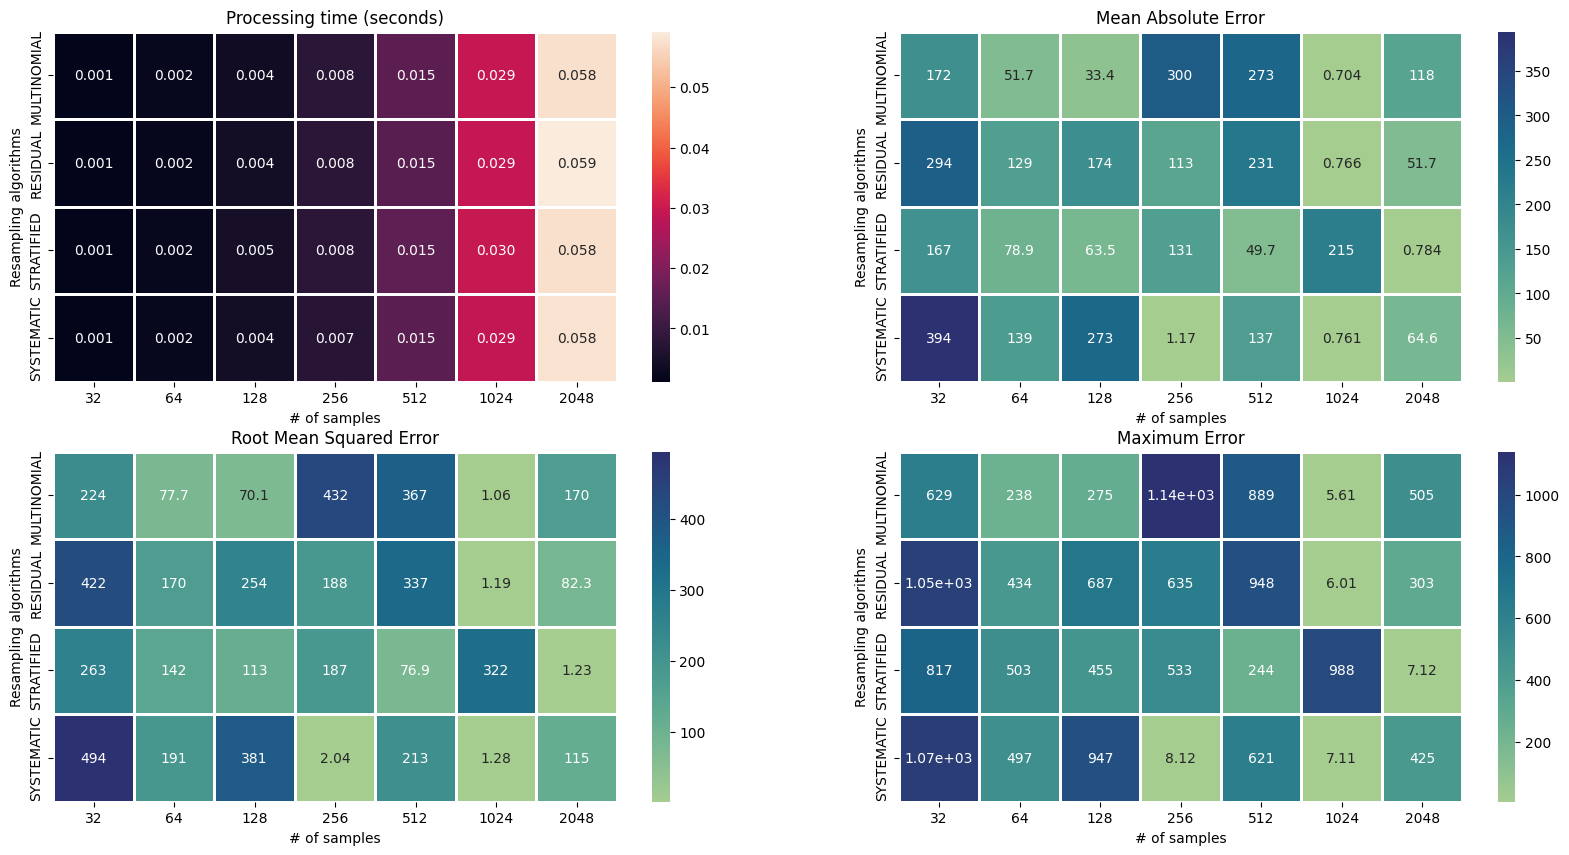

In [28]:
tuner_setup2_10.plot_results()

In [29]:
params_2_10, df_2_10 = tuner_setup2_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_2_10)

In [30]:
df_2_10

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,SYSTEMATIC


## Setup3 (INS)

In [31]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [32]:
if run_filter:
    tuner_setup3_10.run()
else:
    tuner_setup3_10.load_df()

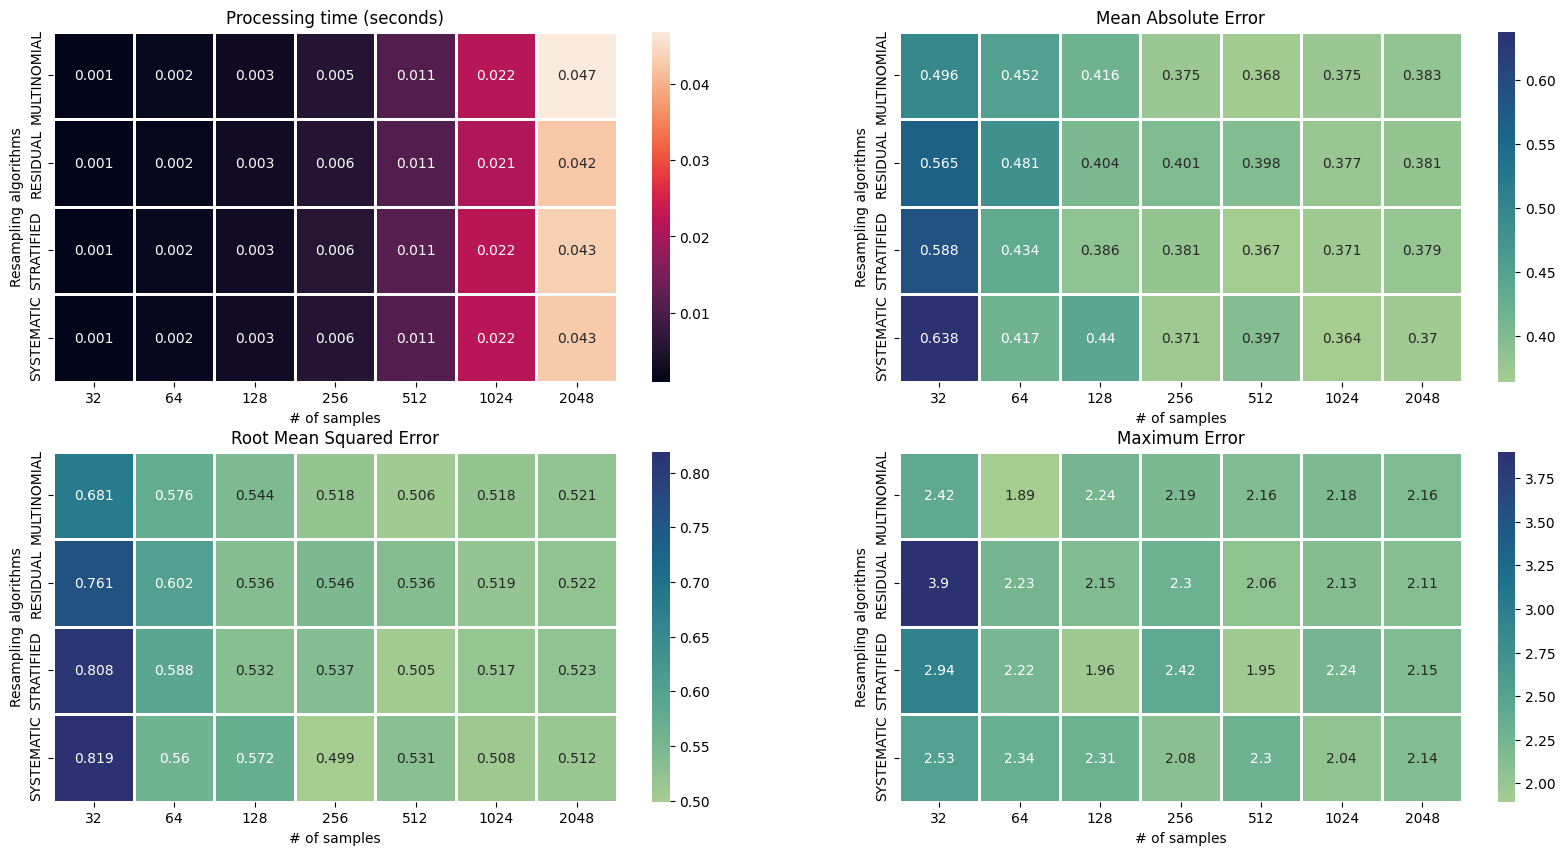

In [33]:
tuner_setup3_10.plot_results()

In [34]:
params_3_10, df_3_10 = tuner_setup3_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_3_10)

In [35]:
df_3_10

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,64,MULTINOMIAL


# 20% dropout measurement data

In [36]:
vo_dropout_ratio = 0.2
gps_dropout_ratio = 0.2

## Setup1 (IMU, VO)

In [37]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [38]:
if run_filter:
    tuner_setup1_20.run()
else:
    tuner_setup1_20.load_df()

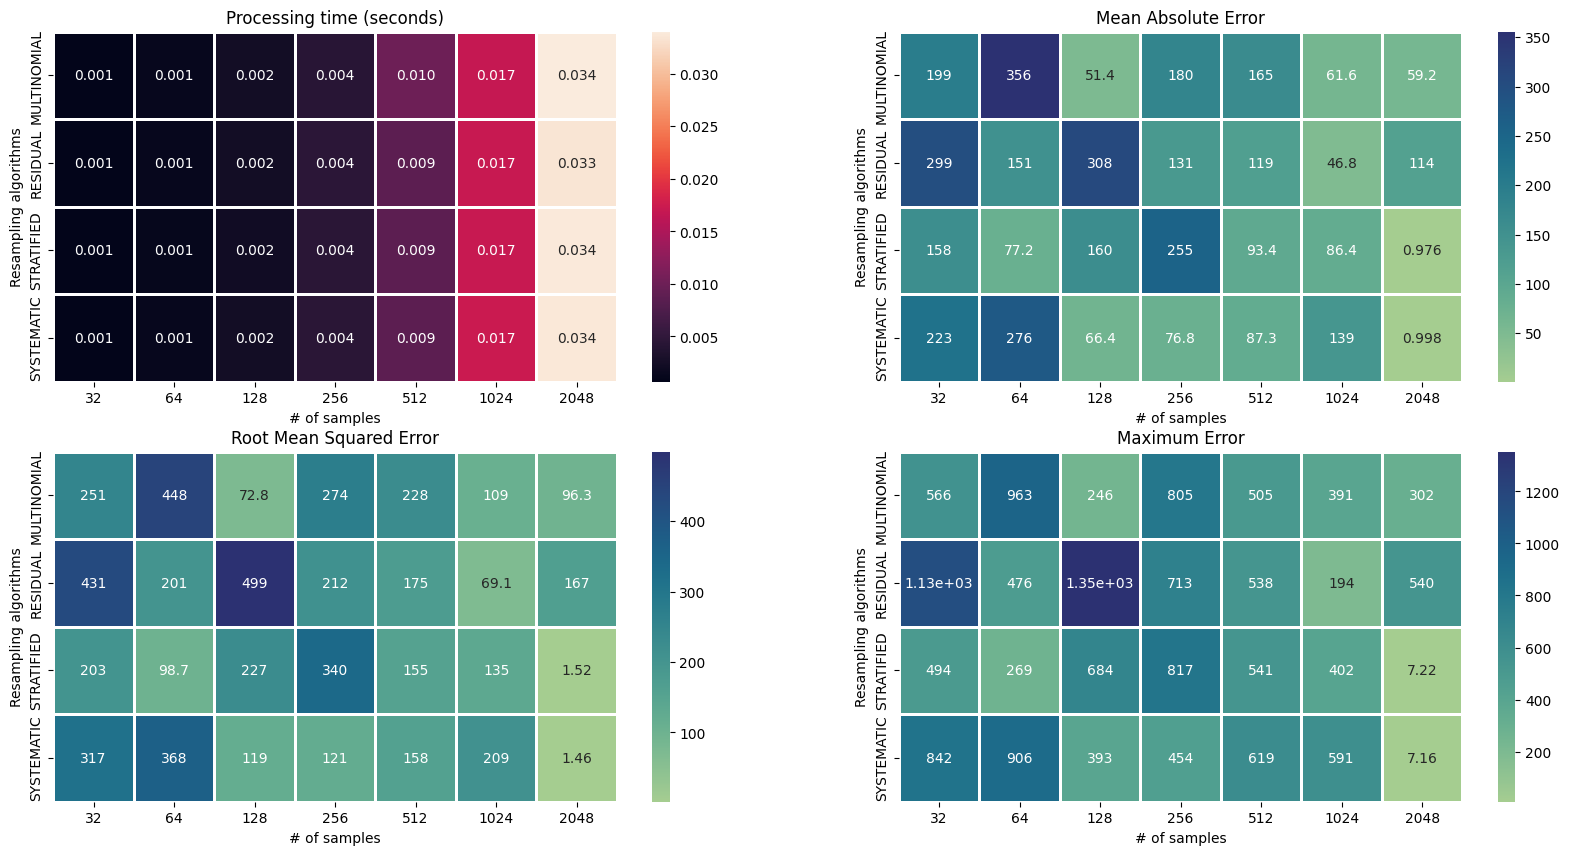

In [39]:
tuner_setup1_20.plot_results()

In [40]:
params_1_20, df_1_20 = tuner_setup1_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_1_20)

In [41]:
df_1_20

,# of samples,resampling algorithm
MAE,2048,SYSTEMATIC
RMSE,2048,SYSTEMATIC
MAX,2048,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [42]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [43]:
if run_filter:
    tuner_setup2_20.run()
else:
    tuner_setup2_20.load_df()

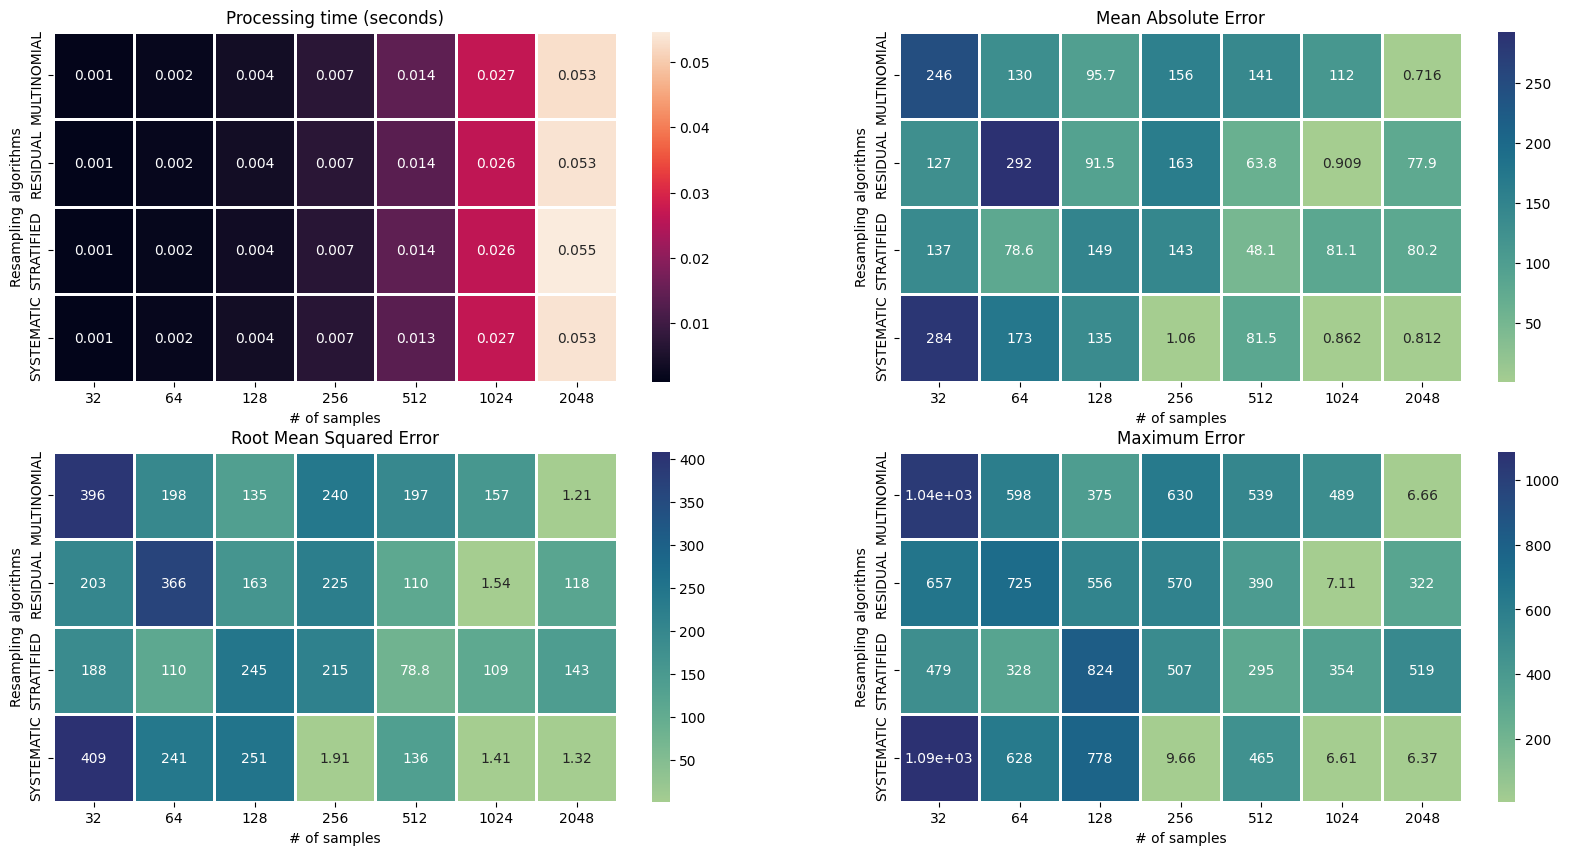

In [44]:
tuner_setup2_20.plot_results()

In [45]:
params_2_20, df_2_20 = tuner_setup2_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_2_20)

In [46]:
df_1_20

,# of samples,resampling algorithm
MAE,2048,SYSTEMATIC
RMSE,2048,SYSTEMATIC
MAX,2048,SYSTEMATIC


## Setup3 (INS)

In [47]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [48]:
if run_filter:
    tuner_setup3_20.run()
else:
    tuner_setup3_20.load_df()

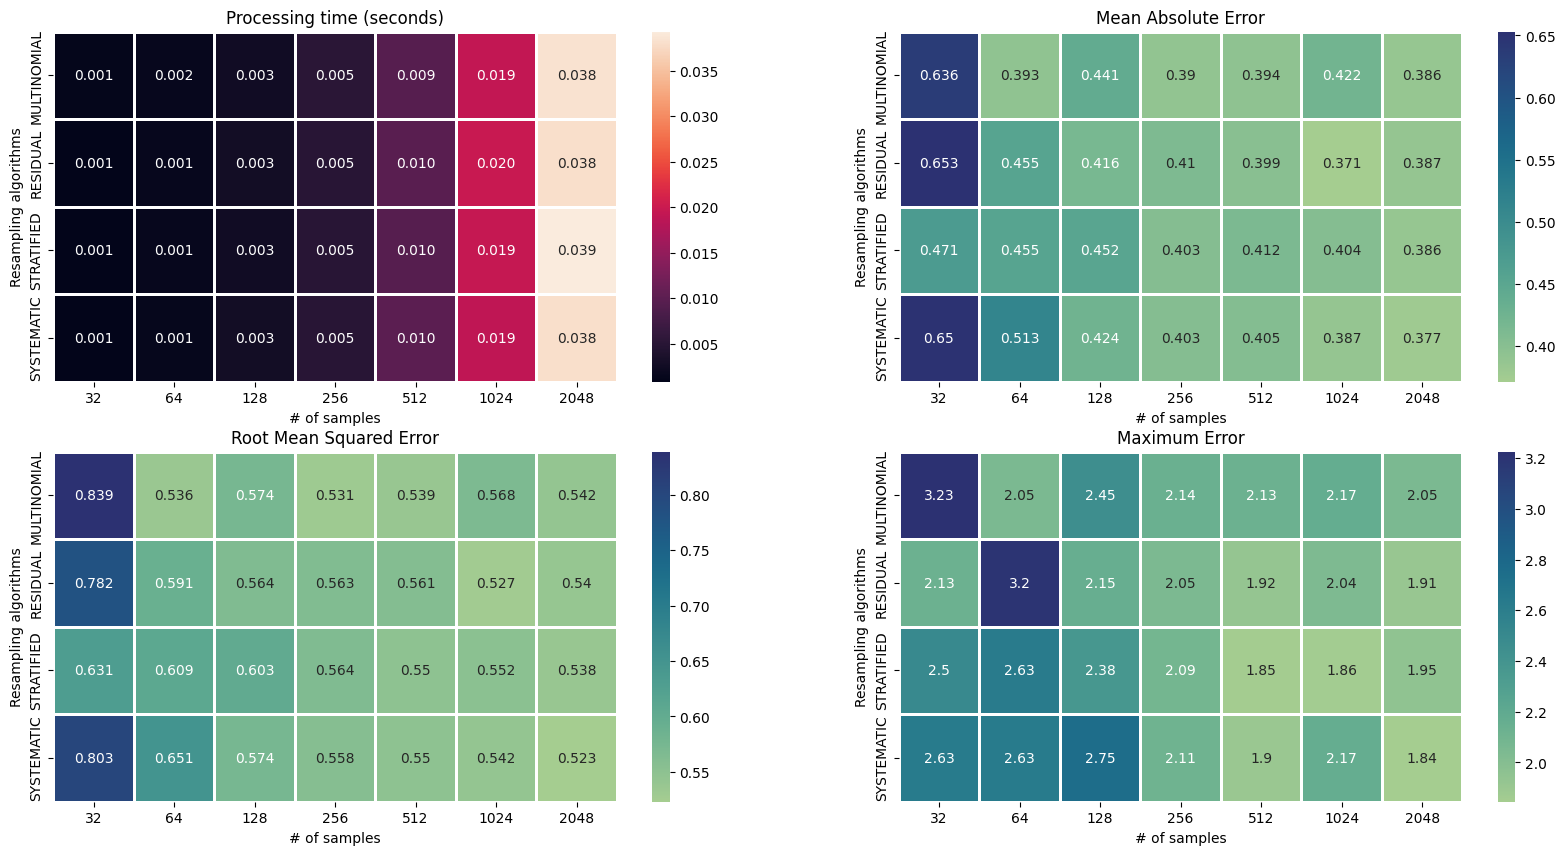

In [49]:
tuner_setup3_20.plot_results()

In [50]:
params_3_20, df_3_20 = tuner_setup3_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_3_20)

In [51]:
df_3_20

,# of samples,resampling algorithm
MAE,64,MULTINOMIAL
RMSE,64,MULTINOMIAL
MAX,512,STRATIFIED


# 30% dropout measurement data

In [52]:
vo_dropout_ratio = 0.3
gps_dropout_ratio = 0.3

## Setup1 (IMU, VO)

In [53]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [54]:
if run_filter:
    tuner_setup1_30.run()
else:
    tuner_setup1_30.load_df()

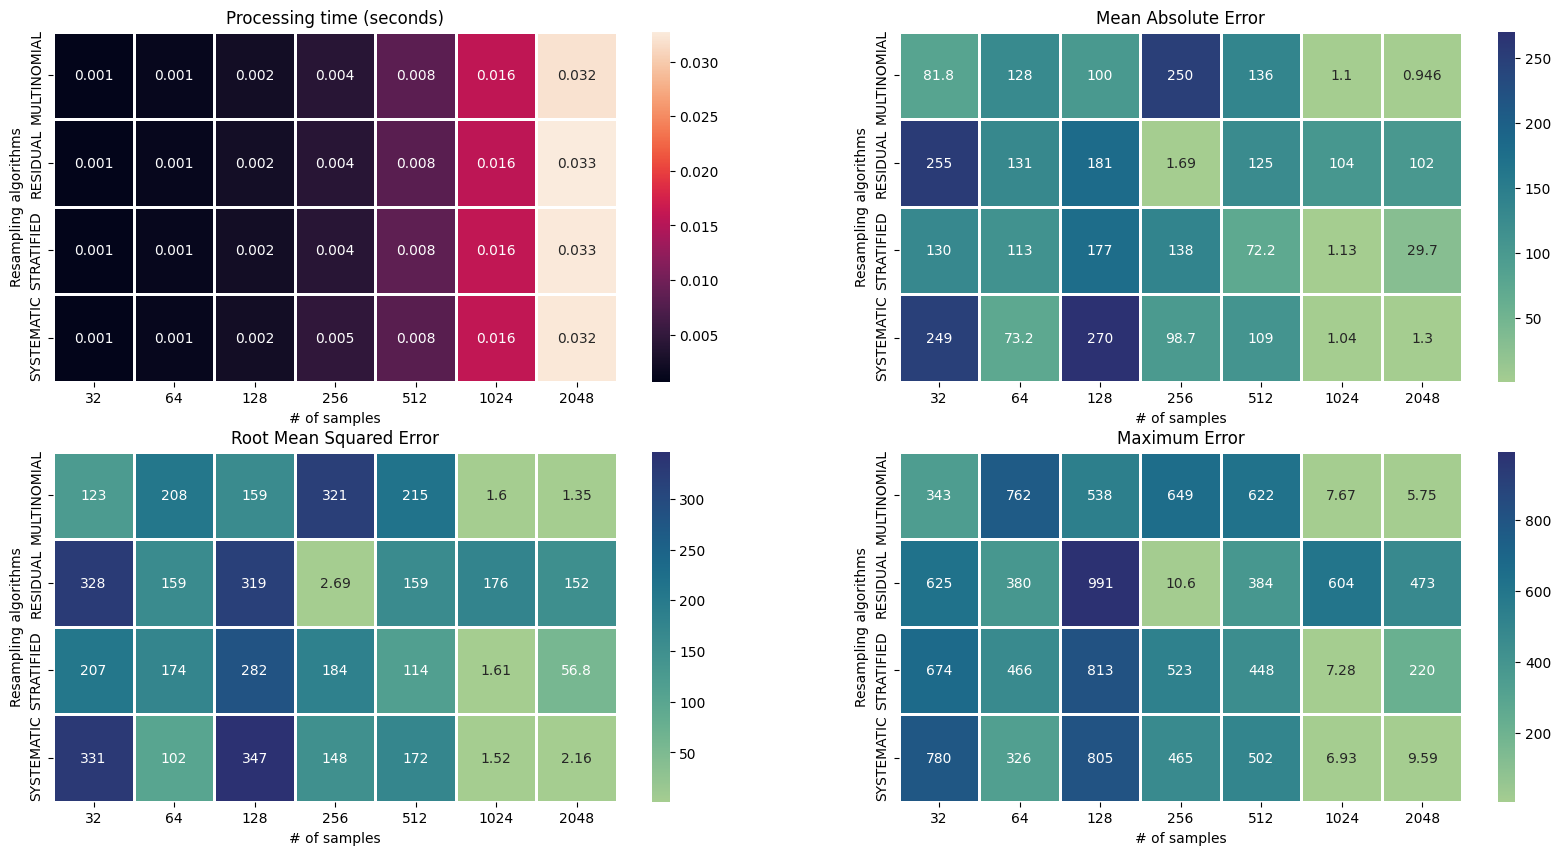

In [55]:
tuner_setup1_30.plot_results()

In [56]:
params_1_30, df_1_30 = tuner_setup1_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_1_30)

In [57]:
df_1_30

,# of samples,resampling algorithm
MAE,256,RESIDUAL
RMSE,256,RESIDUAL
MAX,256,RESIDUAL


## Setup2 (IMU, VO+GPS)

In [58]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [59]:
if run_filter:
    tuner_setup2_30.run()
else:
    tuner_setup2_30.load_df()

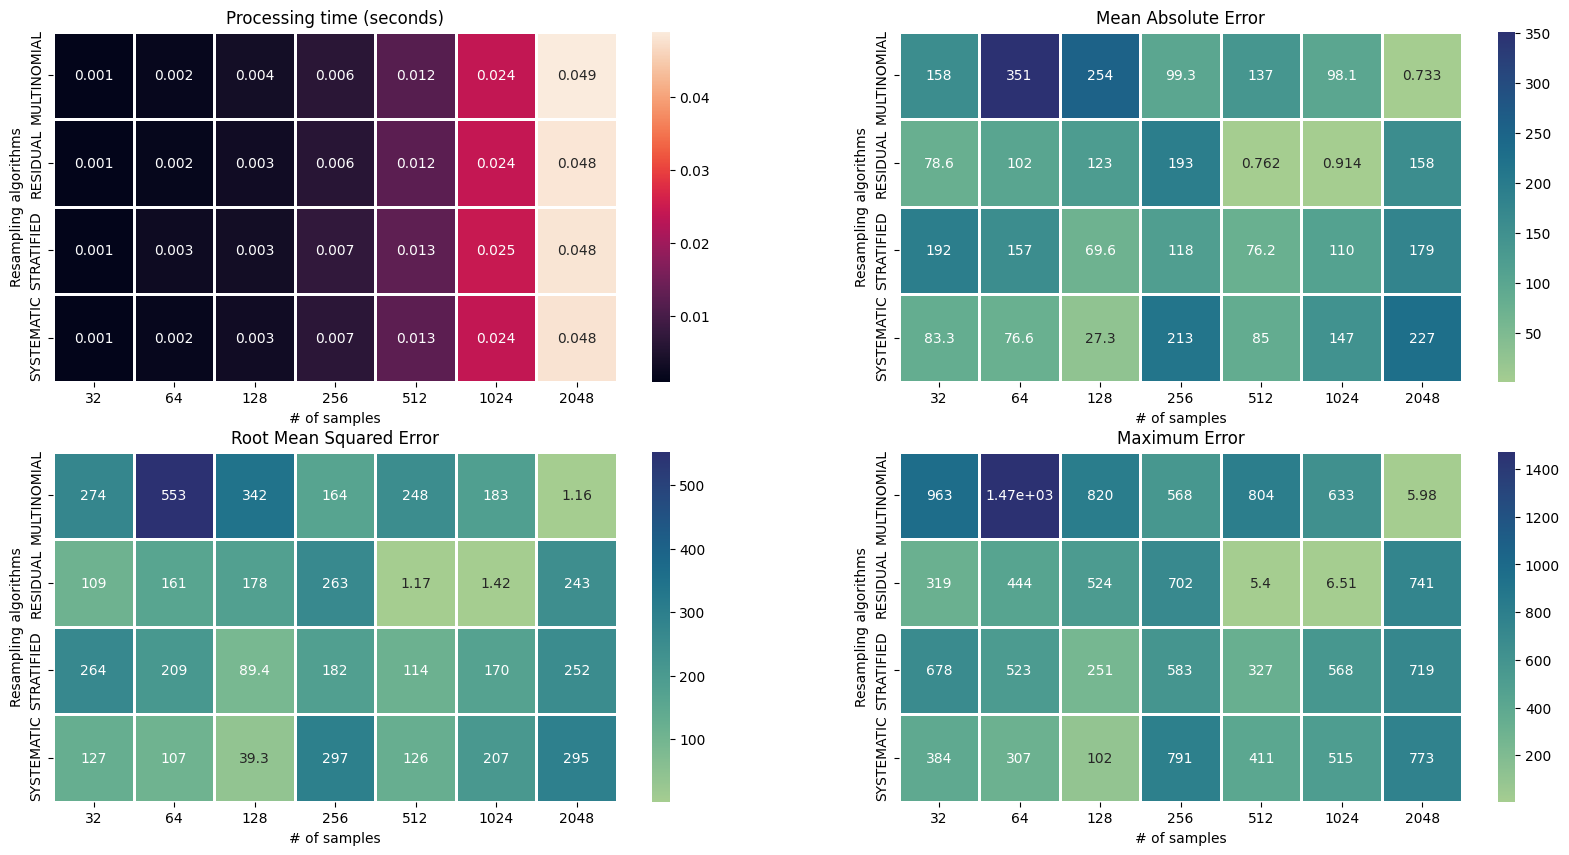

In [60]:
tuner_setup2_30.plot_results()

In [61]:
params_2_30, df_2_30 = tuner_setup2_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_2_30)

In [62]:
df_2_30

,# of samples,resampling algorithm
MAE,512,RESIDUAL
RMSE,512,RESIDUAL
MAX,512,RESIDUAL


## Setup3 (INS)

In [63]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [64]:
if run_filter:
    tuner_setup3_30.run()
else:
    tuner_setup3_30.load_df()

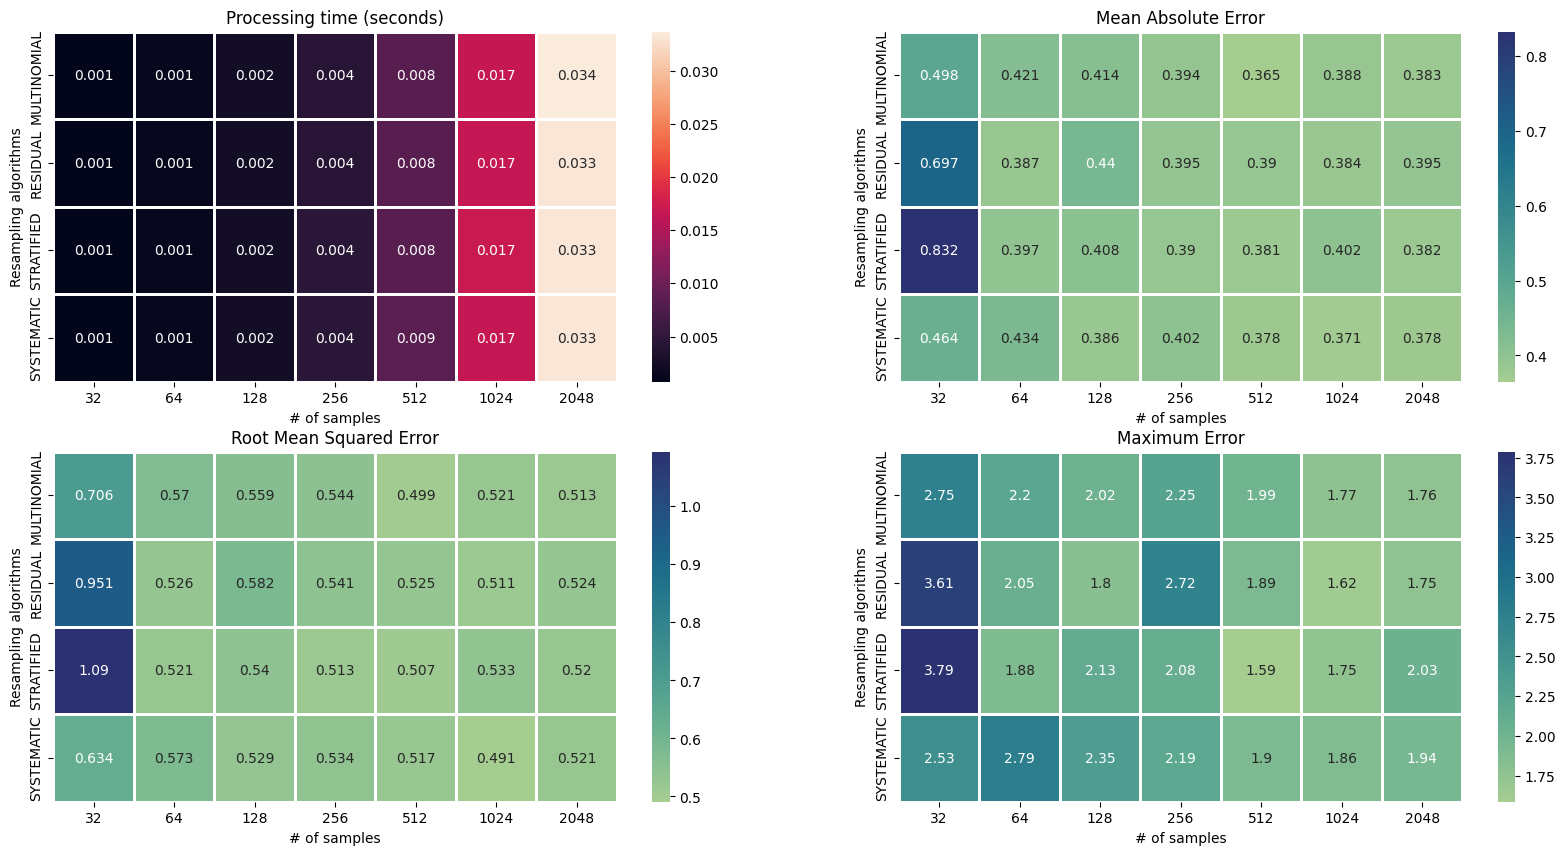

In [65]:
tuner_setup3_30.plot_results()

In [66]:
params_3_30, df_3_30 = tuner_setup3_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_3_30)

In [67]:
df_3_30

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,64,STRATIFIED
MAX,512,STRATIFIED


# 40% dropout measurement data

In [68]:
vo_dropout_ratio = 0.4
gps_dropout_ratio = 0.4

## Setup1 (IMU, VO)

In [69]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [70]:
if run_filter:
    tuner_setup1_40.run()
else:
    tuner_setup1_40.load_df()

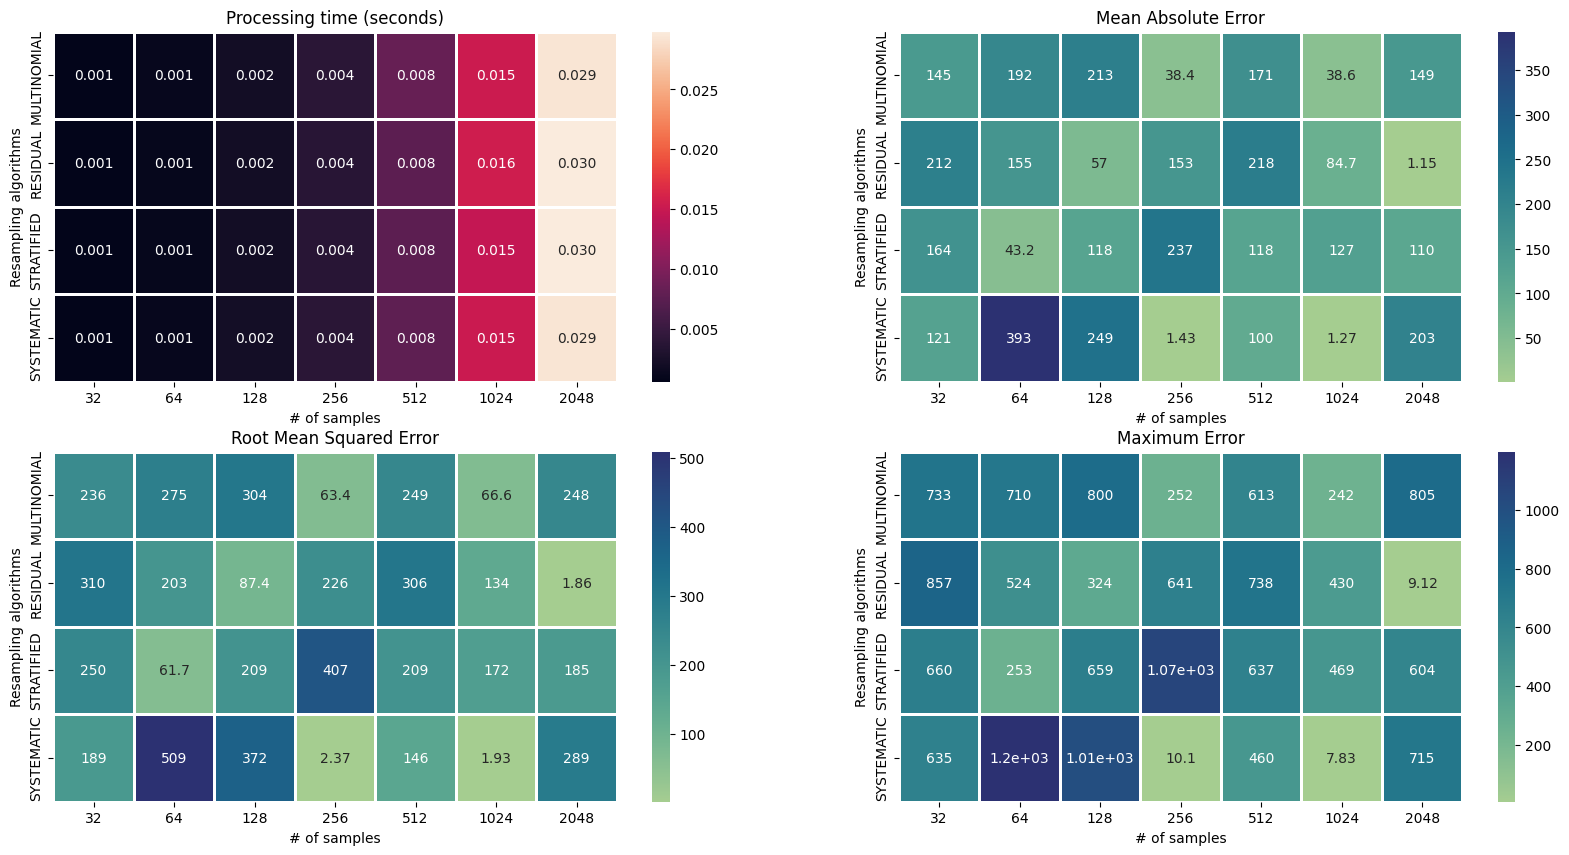

In [71]:
tuner_setup1_40.plot_results()

In [72]:
params_1_40, df_1_40 = tuner_setup1_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_1_40)

In [73]:
df_1_40

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [74]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [75]:
if run_filter:
    tuner_setup2_40.run()
else:
    tuner_setup2_40.load_df()

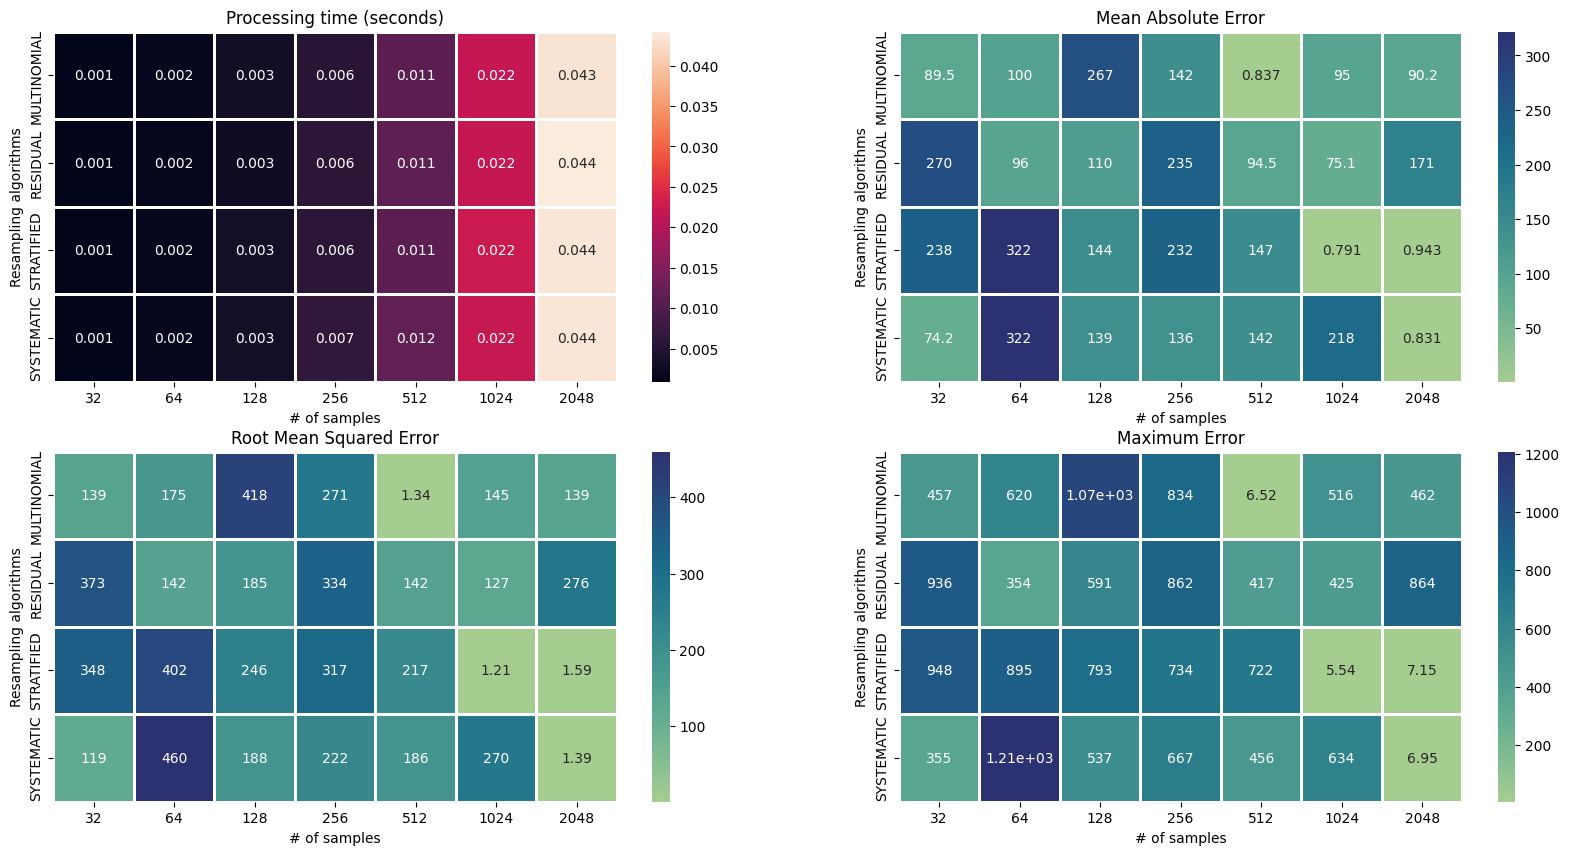

In [76]:
tuner_setup2_40.plot_results()

In [77]:
params_2_40, df_2_40 = tuner_setup2_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_2_40)

In [78]:
df_2_40

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,512,MULTINOMIAL


## Setup3 (INS)

In [79]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [80]:
if run_filter:
    tuner_setup3_40.run()
else:
    tuner_setup3_40.load_df()

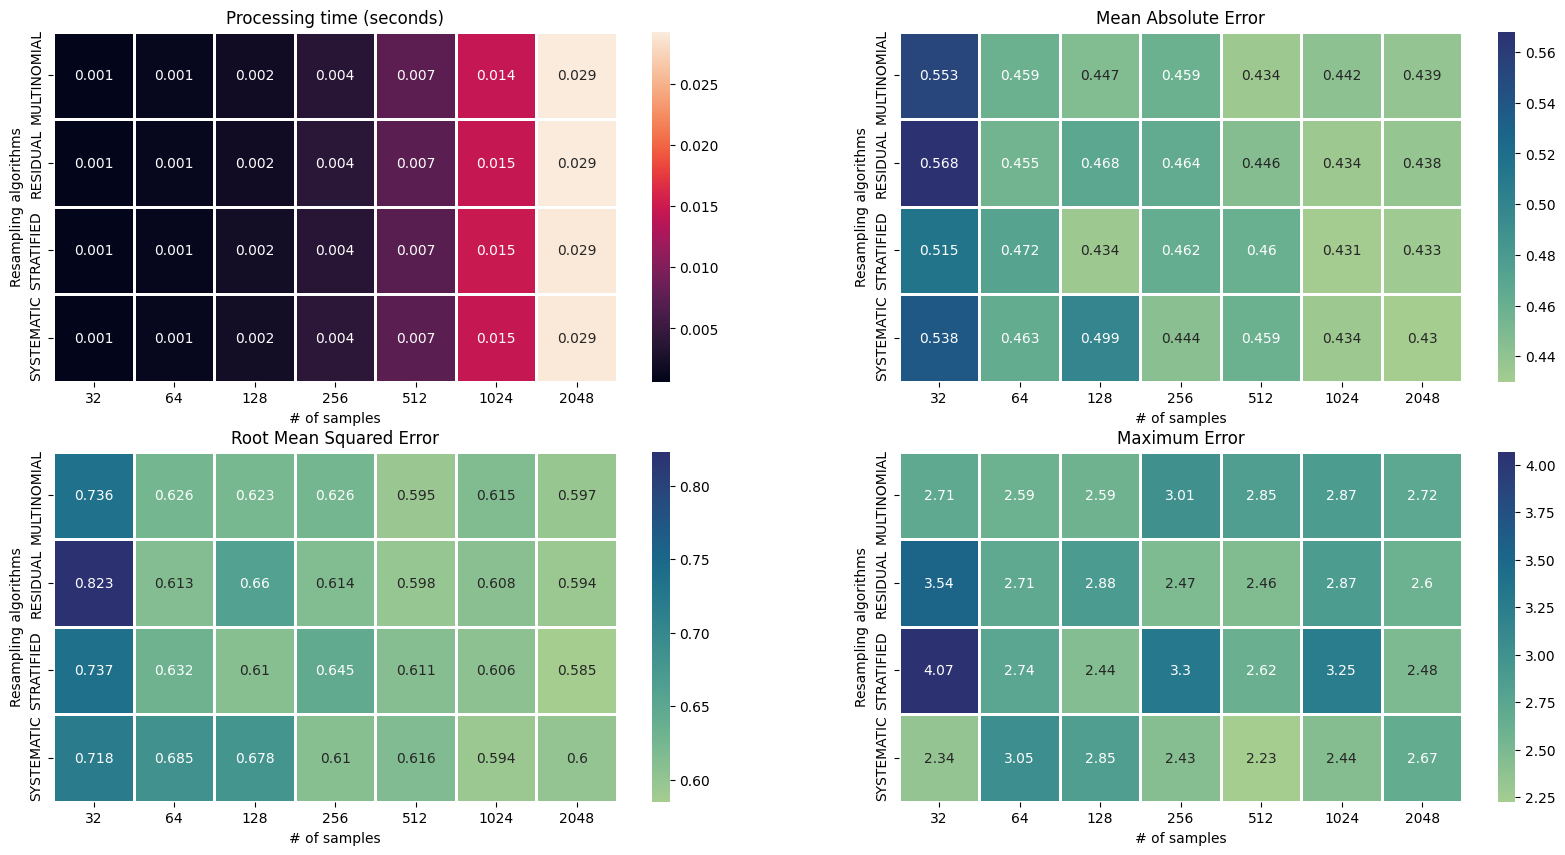

In [81]:
tuner_setup3_40.plot_results()

In [82]:
params_3_40, df_3_40 = tuner_setup3_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_3_40)

In [83]:
df_3_40

,# of samples,resampling algorithm
MAE,128,STRATIFIED
RMSE,128,STRATIFIED
MAX,512,SYSTEMATIC


# Results

In [84]:
best_params_0_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_0_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_0_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_10_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_10_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_10_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_20_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_20_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_20_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_30_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_30_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_30_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_40_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_40_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_40_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_mae = [best_params_0_mae, best_params_10_mae, best_params_20_mae, best_params_30_mae, best_params_40_mae]
best_params_rmse = [best_params_0_rmse, best_params_10_rmse, best_params_20_rmse, best_params_30_rmse, best_params_40_rmse]
best_params_max = [best_params_0_max, best_params_10_max, best_params_20_max, best_params_30_max, best_params_40_max]

In [85]:
best_params_mae

[['1024', 'RESIDUAL', '256', 'STRATIFIED', '512', 'MULTINOMIAL'],
 ['1024', 'MULTINOMIAL', '256', 'SYSTEMATIC', '256', 'SYSTEMATIC'],
 ['2048', 'SYSTEMATIC', '256', 'SYSTEMATIC', '64', 'MULTINOMIAL'],
 ['256', 'RESIDUAL', '512', 'RESIDUAL', '512', 'MULTINOMIAL'],
 ['256', 'SYSTEMATIC', '512', 'MULTINOMIAL', '128', 'STRATIFIED']]

In [86]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)'],
                                             ['# of samples', 'Resampling algorithm']],
                                            names=['Setups','Parameters'])


#### MAE

In [87]:
best_params_df = pd.DataFrame(best_params_mae, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)
best_params_df

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout             1024             RESIDUAL                 256   
10% drop               1024          MULTINOMIAL                 256   
20% drop               2048           SYSTEMATIC                 256   
30% drop                256             RESIDUAL                 512   
40% drop                256           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          512          MULTINOMIAL  
10% drop             SYSTEMATIC          256           SYSTEMATIC  
20% drop             SYSTEMATIC           64          MULTINOMIAL  
30% drop               RESIDUAL          512          MULTINOMIAL  
40% drop            MULTINOMIAL          128           STRATIFIED

#### RMSE

In [88]:
pd.DataFrame(best_params_rmse, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout             1024             RESIDUAL                 256   
10% drop               1024          MULTINOMIAL                 256   
20% drop               2048           SYSTEMATIC                 256   
30% drop                256             RESIDUAL                 512   
40% drop                256           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          512          MULTINOMIAL  
10% drop             SYSTEMATIC          256           SYSTEMATIC  
20% drop             SYSTEMATIC           64          MULTINOMIAL  
30% drop               RESIDUAL           64           STRATIFIED  
40% drop            MULTINOMIAL          128           STRATIFIED

#### MAX

In [89]:
pd.DataFrame(best_params_max, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              512           SYSTEMATIC                 256   
10% drop               1024          MULTINOMIAL                 256   
20% drop               2048           SYSTEMATIC                 256   
30% drop                256             RESIDUAL                 512   
40% drop                256           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          256           SYSTEMATIC  
10% drop             SYSTEMATIC           64          MULTINOMIAL  
20% drop             SYSTEMATIC          512           STRATIFIED  
30% drop               RESIDUAL          512           STRATIFIED  
40% drop            MULTINOMIAL          512           SYSTEMATIC

## Export the result

In [90]:
best_params_df.to_json(exporting_filename)

# Conclusion

In this notebook, we applied manual search to find optimal parameters used in Particle Filter.
According to the experiment, based on MAE metric, we found that the optimal parameters, particle size and resampling algorithm for each setup is that:
- Setup1 (IMU, VO):
    - Number of samples    : 2048
    - Resampling algorithm : SYSTEMATIC
- Setup2 (IMU, VO+GPS):
    - Number of samples    : 512
    - Resampling algorithm : MULTINOMIAL
- Setup3 (INS, VO+GPS):
    - Number of samples    : 512
    - Resampling algorithm : MULTINOMIAL

To avoid common PF problems so called sample degeneracy and impoverishment, we can set the number fo particles to large value, say 1024 or 2048. However, particle size and computational power is trade-off so that we discover the balance between them in this experiment.

Moreover, in this sequence number 04, setup1 and setup2 have poor estimations and the optimal parameters are unselectable since estimation errors are uncorrelated to the change of particle size. 